<a href="https://colab.research.google.com/github/sYanXO/Volatility-Regime-Analysis/blob/main/Arch_and_Garch_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Voltility is clustered over periods of time, i.e a large jump in volatility is generally followed by a larger change just like ripples in a pond. Which then gradually subside.

Natural stat models assume volatility to be constant over time but that isn't the case in reality. there arch and garch models help us model the volatility clusterings much better.

Arch stands for Autoregressive Conditional Heteroskedasticity -> heteroskedasticy stands for change of spread or variance ie how big are the open and close values over the course of a timeline.

Conditional cuz tomorrow's value depends on today's value

Autoregressive just means trying to predict future from past values

In [15]:
pip install yfinance pandas matplotlib arch

In [16]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from arch import arch_model
import numpy as np

In [17]:
ticker = "RELIANCE.NS"

data = yf.download(ticker, period="10y")


/tmp/ipykernel_448/760960769.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="10y")
[*********************100%***********************]  1 of 1 completed


In [18]:
data["Return"] = np.log(data["Close"] / data["Close"].shift(1))*100
data.dropna()

Price,Close,High,Low,Open,Volume,Return
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,
Date,,,,,,
2016-03-15,221.125946,222.718571,219.955857,221.884333,10487788,0.073517
2016-03-16,221.396790,222.274363,217.864856,221.234281,11064129,0.122409
2016-03-17,222.629578,227.209262,221.753079,225.039942,16832997,0.555278
2016-03-18,225.083755,225.730166,222.563833,223.122597,14030979,1.096328
2016-03-21,227.296890,228.217212,224.108645,225.248085,12708074,0.978447
...,...,...,...,...,...,...
2026-03-09,1424.000000,1429.400024,1370.000000,1375.000000,24870822,1.357483
2026-03-10,1408.800049,1431.500000,1400.599976,1430.599976,18071259,-1.073150


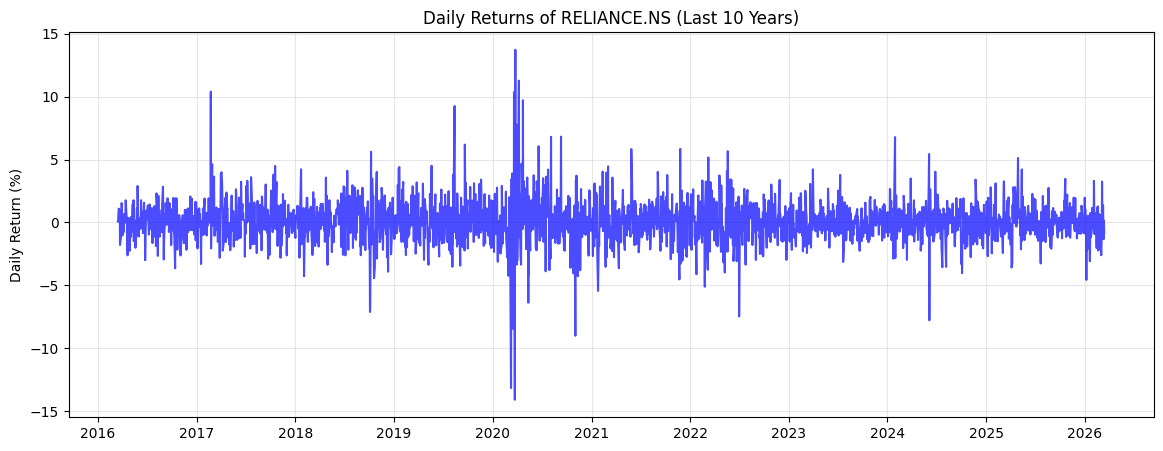

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['Return'], color='blue', alpha=0.7)
plt.title(f"Daily Returns of {ticker} (Last 10 Years)")
plt.ylabel("Daily Return (%)")
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
returns = data["Return"].dropna()
arch_m = arch_model(returns, mean="Zero", vol="ARCH", p=1)
arch_results = arch_m.fit(disp='off') # disp='off' hides the optimization steps

print("--- ARCH(1) MODEL RESULTS ---")
print(arch_results.summary())

--- ARCH(1) MODEL RESULTS ---
                        Zero Mean - ARCH Model Results                        
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -4688.04
Distribution:                  Normal   AIC:                           9380.07
Method:            Maximum Likelihood   BIC:                           9391.69
                                        No. Observations:                 2470
Date:                Sun, Mar 15 2026   Df Residuals:                     2470
Time:                        15:44:44   Df Model:                            0
                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          2.1454      0.148     14.

**The ARCH model suggests that Reliance shows volatility clustering, because a large move on one day tends to increase expected volatility on the next day.**



omega = normal background volatility,
alpha[1] = how much yesterday’s move increases today’s expected volatility

In [23]:
from arch import arch_model

returns = data["Return"].dropna()

garch_m = arch_model(returns, mean="Zero", vol="GARCH", p=1, q=1)
garch_results = garch_m.fit(disp="off")

print(garch_results.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4580.72
Distribution:                  Normal   AIC:                           9167.45
Method:            Maximum Likelihood   BIC:                           9184.89
                                        No. Observations:                 2470
Date:                Sun, Mar 15 2026   Df Residuals:                     2470
Time:                        16:00:47   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1448  6.715e-02      2.157  3.104e-02 [1.320e-0

alpha + beta = 0.9461

It means volatility is highly persistent.

**Reliance returns exhibit volatility clustering. The GARCH(1,1) model shows that both recent shocks and past volatility affect current volatility, with past volatility having the stronger effect. Since alpha + beta is close to 1, volatility is highly persistent.**

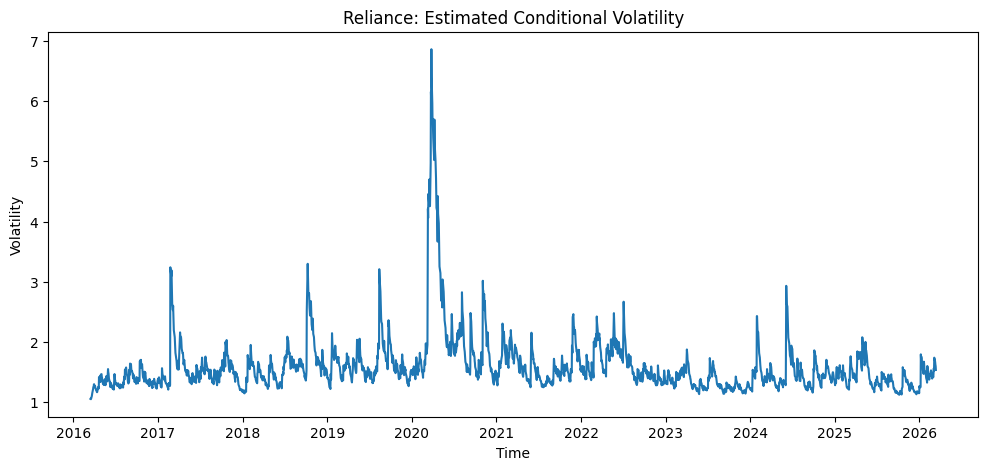

In [24]:
import matplotlib.pyplot as plt

cond_vol = garch_results.conditional_volatility

plt.figure(figsize=(12,5))
plt.plot(cond_vol)
plt.title("Reliance: Estimated Conditional Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

The GARCH(1,1) model for Reliance suggests that volatility is time-varying and strongly persistent. The estimated conditional volatility plot shows clear clustering, where high-volatility periods are followed by further elevated volatility and calm periods remain relatively stable. The large spike around 2020 and the gradual decline afterward illustrate that volatility shocks do not disappear immediately, which is consistent with the high beta coefficient and the large alpha + beta value from the model.

**Plotting Volatility against actual returns**




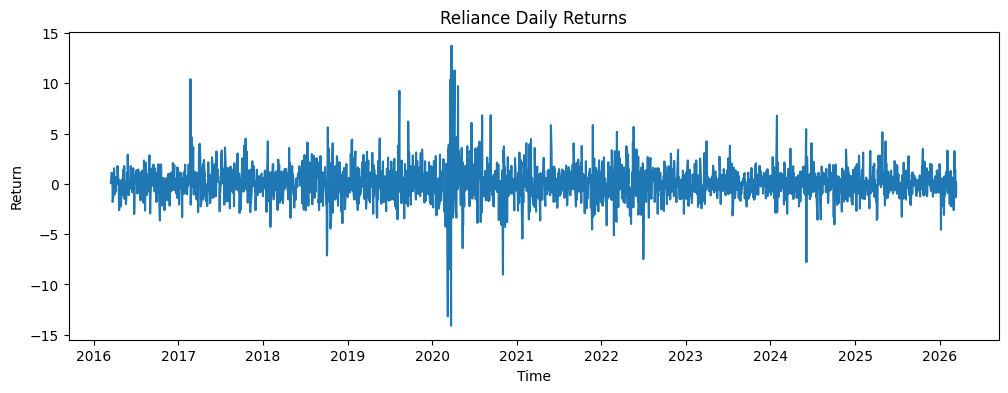

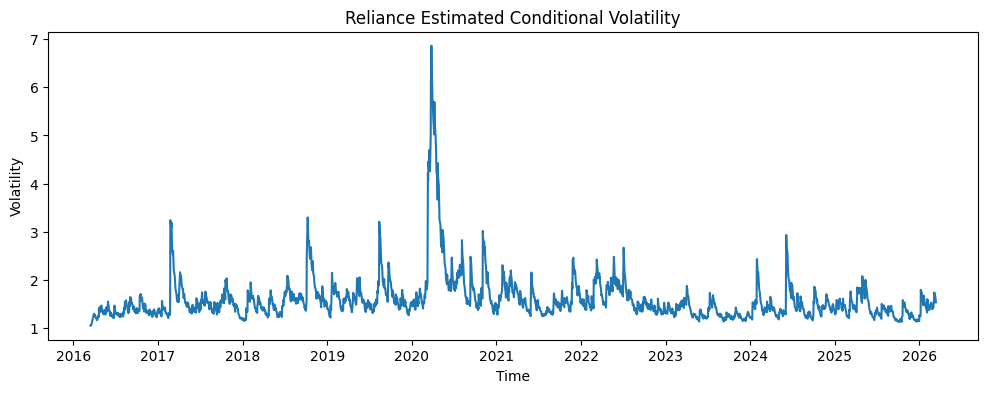

In [25]:
import matplotlib.pyplot as plt

returns = data["Return"].dropna()
cond_vol = garch_results.conditional_volatility

plt.figure(figsize=(12, 4))
plt.plot(returns)
plt.title("Reliance Daily Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(cond_vol)
plt.title("Reliance Estimated Conditional Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

Periods with large return swings correspond to higher estimated conditional volatility, suggesting that the GARCH model captures time-varying risk reasonably well.

In [27]:
from arch import arch_model

returns = data["Return"].dropna()

garch_t = arch_model(returns, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
garch_t_results = garch_t.fit(disp="off")

print(garch_t_results.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                       Return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4467.82
Distribution:      Standardized Student's t   AIC:                           8943.64
Method:                  Maximum Likelihood   BIC:                           8966.89
                                              No. Observations:                 2470
Date:                      Sun, Mar 15 2026   Df Residuals:                     2470
Time:                              16:09:45   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

In [28]:
print("Normal GARCH")
print("AIC:", garch_results.aic)
print("BIC:", garch_results.bic)
print("Log-Likelihood:", garch_results.loglikelihood)

print("\nStudent-t GARCH")
print("AIC:", garch_t_results.aic)
print("BIC:", garch_t_results.bic)
print("Log-Likelihood:", garch_t_results.loglikelihood)

Normal GARCH
AIC: 9167.449607424152
BIC: 9184.885527713019
Log-Likelihood: -4580.724803712076

Student-t GARCH
AIC: 8943.640642930575
BIC: 8966.888536649063
Log-Likelihood: -4467.820321465288


Reliance returns contain extreme observations that are better handled by a Student-t distribution than a Normal one.

The Student-t GARCH model fits Reliance returns better than the Normal GARCH model, as shown by lower AIC and BIC values and a higher log-likelihood. This suggests that Reliance returns have heavier tails, meaning extreme daily moves occur more often than a Normal distribution would predict.

In [31]:
# Comparing with another ticker TCS.NS

ticker = "TCS.NS"

second_data = yf.download(ticker, period="10y")

/tmp/ipykernel_448/2379979873.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  second_data = yf.download(ticker, period="10y")
[*********************100%***********************]  1 of 1 completed


In [32]:
second_data["Return"] = second_data["Close"].pct_change() * 100

In [33]:
from arch import arch_model

second_returns = second_data["Return"].dropna()

second_garch = arch_model(second_returns, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
second_results = second_garch.fit(disp="off")

print(second_results.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                       Return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4284.91
Distribution:      Standardized Student's t   AIC:                           8577.83
Method:                  Maximum Likelihood   BIC:                           8601.08
                                              No. Observations:                 2470
Date:                      Sun, Mar 15 2026   Df Residuals:                     2470
Time:                              16:14:25   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

TCS also shows strong volatility clustering, and the persistence is very strong.

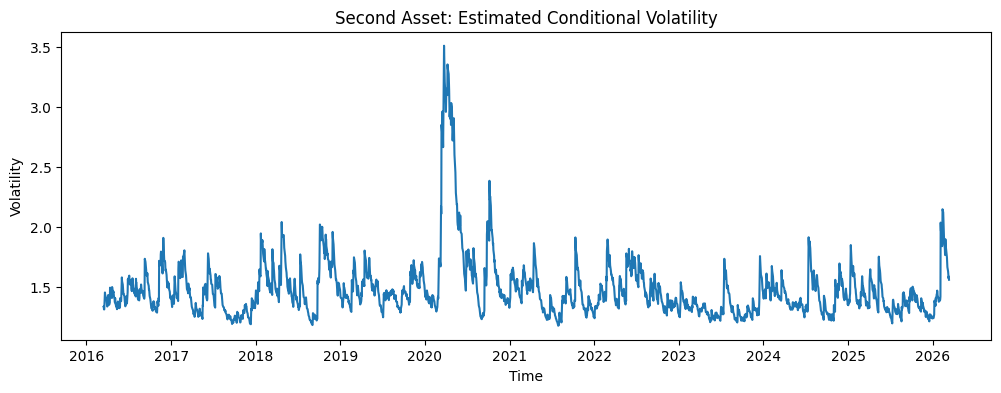

In [34]:
second_cond_vol = second_results.conditional_volatility

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(second_cond_vol)
plt.title("Second Asset: Estimated Conditional Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

Reliance seems to have a somewhat higher background volatility level than TCS.
Reliance reacts more strongly to new shocks than TCS.

once TCS volatility rises, it tends to stay elevated for longer.both stocks show strong volatility clustering, but TCS appears slightly more persistent.

In [36]:
import pandas as pd

# Reliance values
rel_omega = garch_t_results.params["omega"]
rel_alpha = garch_t_results.params["alpha[1]"]
rel_beta  = garch_t_results.params["beta[1]"]
rel_ab    = rel_alpha + rel_beta
rel_aic   = garch_t_results.aic
rel_bic   = garch_t_results.bic

# TCS values
tcs_omega = second_results.params["omega"]
tcs_alpha = second_results.params["alpha[1]"]
tcs_beta  = second_results.params["beta[1]"]
tcs_ab    = tcs_alpha + tcs_beta
tcs_aic   = second_results.aic
tcs_bic   = second_results.bic

comparison = pd.DataFrame({
    "Stock": ["Reliance", "TCS"],
    "Omega (Baseline Vol)": [rel_omega, tcs_omega],
    "Alpha (Shock Reaction)": [rel_alpha, tcs_alpha],
    "Beta (Persistence)": [rel_beta, tcs_beta],
    "Alpha + Beta": [rel_ab, tcs_ab],
    "AIC": [rel_aic, tcs_aic],
    "BIC": [rel_bic, tcs_bic]
})

comparison = comparison.round(4)
display(comparison)

,Stock,Omega (Baseline Vol),Alpha (Shock Reaction),Beta (Persistence),Alpha + Beta,AIC,BIC
0,Reliance,0.0826,0.0556,0.9126,0.9682,8943.6406,8966.8885
1,TCS,0.1035,0.0448,0.9105,0.9553,8577.8278,8601.0757


In [37]:
comparison["Interpretation"] = [
    "More reactive to shocks",
    "More persistent volatility"
]

comparison

,Stock,Omega (Baseline Vol),Alpha (Shock Reaction),Beta (Persistence),Alpha + Beta,AIC,BIC,Interpretation
0,Reliance,0.0826,0.0556,0.9126,0.9682,8943.6406,8966.8885,More reactive to shocks
1,TCS,0.1035,0.0448,0.9105,0.9553,8577.8278,8601.0757,More persistent volatility


**A comparison of Student-t GARCH(1,1) estimates for Reliance and TCS shows that both stocks exhibit strong volatility clustering, as indicated by high beta coefficients and large alpha + beta values. Reliance has a higher omega and alpha, suggesting a higher baseline volatility and stronger immediate reaction to shocks. TCS has a higher beta and slightly larger alpha + beta, indicating more persistent volatility once it rises.**